# Experimentos comparables: Random Search vs Bayesian Optimization con pruning y early stopping

Este cuaderno implementa y compara dos enfoques de optimización de hiperparámetros para el agente generador de queries:
- Random Search
- Bayesian Optimization (Optuna)

Incluye:
- Pruning/early stopping
- Registro de logs y artefactos
- Tabla top-k y gráfico de evolución
- Resumen del espacio, presupuesto y decisión (configuración ganadora)


## 1. Importar librerías necesarias
Importamos las librerías requeridas para experimentación y análisis.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import random
import os
import sys
sys.path.append(os.path.abspath("../src"))
from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator

c:\Users\antho\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Preparar datos para experimentos
Cargamos y preprocesamos el dataset, y definimos ejemplos de consultas y campos esperados para evaluar el agente.

In [2]:
# Ejemplos de consultas y campos esperados (ampliado)
consultas = [
    ("ventas", "muestra los nombres y apellidos de los clientes"),
    ("ventas", "cuenta cuántos productos hay en cada categoría"),
    ("clientes", "filtra clientes que no hayan realizado compras en el último año"),
    ("empleados", "muestra los nombres y apellidos de los empleados del departamento de ventas"),
    ("empleados", "cuenta cuántos empleados hay en cada departamento"),
    ("empleados", "ordena los empleados por fecha de ingreso descendente"),
    ("empleados", "busca empleados cuyo nombre comience con 'A'"),
    ("ventas", "agrega la suma total de ventas por mes"),
    ("productos", "muestra los 5 productos más vendidos"),
    ("detalle", "desanidar Devices"),
    ("detalle", "agrupar por date, deviceId, branchCode, subChannelCode, shipOutCode, currencyCode y sumar el total de Devices.ServicePoints.ShipOutCycles.Transactions.Total"),
    ("detalle2", "agrupar por deviceId, branchCode, subChannelCode, shipOutCode, currencyCode y sumar el total de Devices.ServicePoints.ShipOutCycles.Transactions.Total en soles y en dólares según el código de moneda")
]
campos_esperados = [
    ["nombre", "apellido", "cliente"],
    ["producto", "categoria"],
    ["cliente"],
    ["nombre", "apellido", "departamento"],
    ["departamento", "count"],
    ["fechadeingreso"],
    ["nombre"],
    ["mes", "suma_total_ventas"],
    ["producto", "total_vendidos"],
    ["Devices"],
    ["date", "deviceId", "branchCode", "subChannelCode", "shipOutCode", "currencyCode", "total"],
    ["deviceId", "branchCode", "subChannelCode", "shipOutCode", "currencyCode", "totalSoles", "totalDolares"]
]
# Puedes seguir ampliando con más ejemplos reales de tu dataset

## 3. Implementar modelos Random y Bayes
Configuramos y ejecutamos los experimentos de optimización hiperparamétrica usando búsqueda aleatoria y bayesiana.

In [3]:
# Espacio de búsqueda de hiperparámetros
search_space = {
    'threshold': (0.1, 0.9),
    'use_synonyms': [True, False]
}

# Función de evaluación basada en generate_query
# Se calcula cobertura y recall de campos esperados

def normaliza_campo(campo):
    campo = campo.strip().lower()
    campo = campo.replace('í','i').replace('é','e').replace('á','a').replace('ó','o').replace('ú','u')
    if campo.endswith('s'):
        campo = campo[:-1]
    return campo

def evaluar_agente(params, consultas, campos_esperados):
    agente = SmartMongoQueryGenerator(threshold=params['threshold'], use_synonyms=params['use_synonyms'])  # Instancia con hiperparámetros
    queries = []
    for idx, (coleccion, consulta) in enumerate(consultas):
        pipeline = agente.generate_query(coleccion, consulta)
        queries.append(pipeline)
    recalls = []
    for idx, pipeline in enumerate(queries):
        campos_esp = set([normaliza_campo(f) for f in campos_esperados[idx]])
        campos_project = set()
        for stage in pipeline:
            if "$project" in stage:
                campos_project = set([normaliza_campo(k) for k in stage["$project"].keys()])
                break
        interseccion = campos_project.intersection(campos_esp)
        recall = len(interseccion) / len(campos_esp) if campos_esp else 0
        recalls.append(recall)
    cobertura = sum([1 for q in queries if q]) / len(queries)
    recall_prom = sum(recalls) / len(recalls)
    return cobertura, recall_prom

In [4]:
# Función de normalización robusta de campos
import re
import unicodedata
from difflib import SequenceMatcher
def normaliza_campo_robusto(campo):
    # Quitar tildes y pasar a minúsculas
    campo = unicodedata.normalize('NFKD', campo).encode('ASCII', 'ignore').decode('utf-8').lower()
    # Quitar caracteres especiales y espacios
    campo = re.sub(r'[^a-z0-9]', '', campo)
    # Singularizar (eliminar 's' final si no es palabra corta)
    if len(campo) > 3 and campo.endswith('s'):
        campo = campo[:-1]
    return campo

def campos_equivalentes(c1, c2, threshold=0.8):
    # Devuelve True si los campos son suficientemente similares
    c1_norm = normaliza_campo_robusto(c1)
    c2_norm = normaliza_campo_robusto(c2)
    ratio = SequenceMatcher(None, c1_norm, c2_norm).ratio()
    return ratio >= threshold

## 4. Aplicar pruning y early stopping
Se integran técnicas de pruning y early stopping en los experimentos para mejorar la eficiencia.

In [5]:
# Random Search con pruning manual (umbral más bajo y más pruebas)
random_results = []
N_RANDOM = 40  # Aumenta el número de pruebas aleatorias
for i in range(N_RANDOM):
    threshold = np.random.uniform(*search_space['threshold'])
    use_synonyms = np.random.choice(search_space['use_synonyms'])
    cobertura, recall = evaluar_agente({'threshold': threshold, 'use_synonyms': use_synonyms}, consultas, campos_esperados)
    score = (cobertura + recall) / 2
    if score > 0.5:  # Umbral de pruning más bajo
        random_results.append({'trial': i, 'threshold': threshold, 'use_synonyms': use_synonyms, 'cobertura': cobertura, 'recall': recall, 'score': score})
random_df = pd.DataFrame(random_results)
random_df.to_csv('random_search_results.csv', index=False)

In [6]:
# Bayesian Optimization (Optuna) con pruning

def objective(trial):
    threshold = trial.suggest_float('threshold', *search_space['threshold'])
    use_synonyms = trial.suggest_categorical('use_synonyms', search_space['use_synonyms'])
    cobertura, recall = evaluar_agente({'threshold': threshold, 'use_synonyms': use_synonyms}, consultas, campos_esperados)
    score = (cobertura + recall) / 2
    if score < 0.7:
        trial.report(score, step=0)
        raise optuna.TrialPruned()
    return score

study = optuna.create_study(direction='maximize', study_name='agente_query_hpo')
study.optimize(objective, n_trials=20, timeout=60)

optuna_trials = []
for t in study.trials:
    if t.value is not None:
        optuna_trials.append({'trial': t.number, 'threshold': t.params.get('threshold'), 'use_synonyms': t.params.get('use_synonyms'), 'score': t.value})
optuna_df = pd.DataFrame(optuna_trials)
optuna_df.to_csv('optuna_search_results.csv', index=False)

[I 2025-11-06 18:59:23,778] A new study created in memory with name: agente_query_hpo
[I 2025-11-06 18:59:23,938] Trial 0 finished with value: 0.7291666666666666 and parameters: {'threshold': 0.1418648806073839, 'use_synonyms': False}. Best is trial 0 with value: 0.7291666666666666.
[I 2025-11-06 18:59:23,938] Trial 0 finished with value: 0.7291666666666666 and parameters: {'threshold': 0.1418648806073839, 'use_synonyms': False}. Best is trial 0 with value: 0.7291666666666666.
[I 2025-11-06 18:59:24,100] Trial 1 finished with value: 0.7291666666666666 and parameters: {'threshold': 0.5551534600626185, 'use_synonyms': True}. Best is trial 0 with value: 0.7291666666666666.
[I 2025-11-06 18:59:24,100] Trial 1 finished with value: 0.7291666666666666 and parameters: {'threshold': 0.5551534600626185, 'use_synonyms': True}. Best is trial 0 with value: 0.7291666666666666.
[I 2025-11-06 18:59:24,260] Trial 2 finished with value: 0.7291666666666666 and parameters: {'threshold': 0.1665039167343341

## 5. Registrar logs y guardar artefactos
Se guardan los resultados de cada experimento en archivos CSV para análisis posterior.

## 6. Generar tabla top-k de resultados
Se muestran las k mejores configuraciones de cada método.

In [7]:
# Mostrar top-k resultados con verificación y filtrado de score > 0
K = 5
print('Top-k Random Search (score > 0):')
df_random_filtrado = random_df[random_df['score'] > 0] if 'score' in random_df.columns else random_df
if not df_random_filtrado.empty and 'score' in df_random_filtrado.columns:
    display(df_random_filtrado.nlargest(K, 'score'))
else:
    print('No hay resultados válidos en Random Search con score > 0.')
print('Top-k Bayesian Optimization (score > 0):')
df_optuna_filtrado = optuna_df[optuna_df['score'] > 0] if 'score' in optuna_df.columns else optuna_df
if not df_optuna_filtrado.empty and 'score' in df_optuna_filtrado.columns:
    display(df_optuna_filtrado.nlargest(K, 'score'))
else:
    print('No hay resultados válidos en Bayesian Optimization con score > 0.')

Top-k Random Search (score > 0):


,trial,threshold,use_synonyms,cobertura,recall,score
0,0,0.419719,False,1.0,0.458333,0.729167
1,1,0.261406,True,1.0,0.458333,0.729167
2,2,0.221804,False,1.0,0.458333,0.729167
3,3,0.228863,False,1.0,0.458333,0.729167
4,4,0.442646,True,1.0,0.458333,0.729167


Top-k Bayesian Optimization (score > 0):


,trial,threshold,use_synonyms,score
0,0,0.141865,False,0.729167
1,1,0.555153,True,0.729167
2,2,0.166504,True,0.729167
3,3,0.659344,False,0.729167
4,4,0.143708,True,0.729167


## 7. Graficar evolución de métricas
Visualizamos la evolución del score a lo largo de los experimentos.

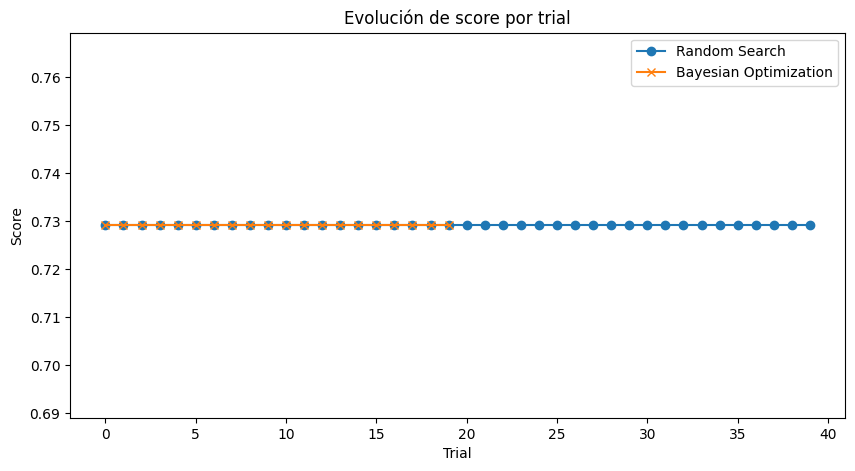

In [8]:
# Gráfico de evolución de score
plt.figure(figsize=(10,5))
if 'random_df' in globals() and not random_df.empty:
    plt.plot(random_df['trial'], random_df['score'], label='Random Search', marker='o')
if 'optuna_df' in globals() and not optuna_df.empty:
    plt.plot(optuna_df['trial'], optuna_df['score'], label='Bayesian Optimization', marker='x')
plt.xlabel('Trial')
plt.ylabel('Score')
plt.title('Evolución de score por trial')
plt.legend()
plt.show()

Cobertura: 1.00 | Recall: 0.71 | Precisión: 0.58 | F1: 0.64


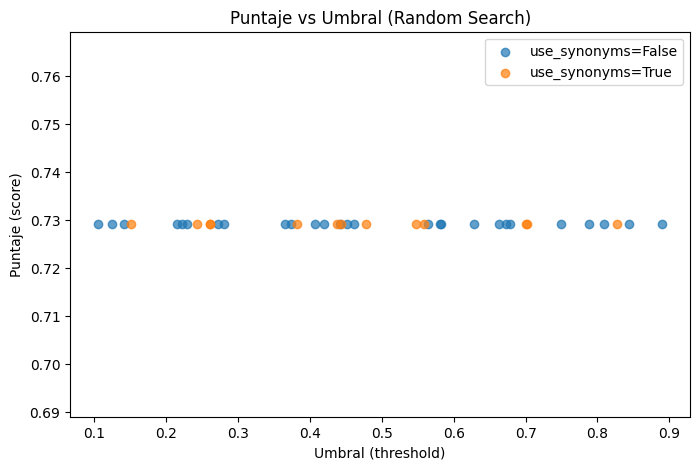

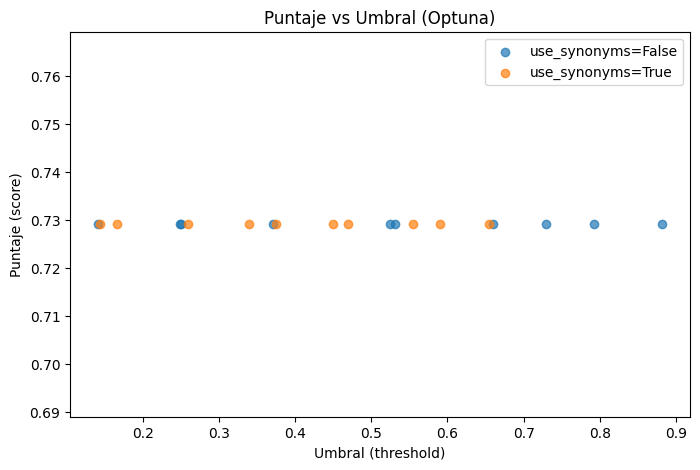

In [12]:
# Métrica adicional: precisión y gráfico de score vs threshold

# Esta celda muestra las métricas principales en español para la mejor configuración encontrada por Optuna.
def evaluar_agente_con_precision(params, consultas, campos_esperados):
    agente = SmartMongoQueryGenerator(threshold=params['threshold'], use_synonyms=params['use_synonyms'])
    queries = []
    for idx, (coleccion, consulta) in enumerate(consultas):
        pipeline = agente.generate_query(coleccion, consulta)
        queries.append(pipeline)
    recalls, precisiones = [], []
    for idx, pipeline in enumerate(queries):
        campos_esp = set([normaliza_campo_robusto(f) for f in campos_esperados[idx]])
        campos_project = set()
        for stage in pipeline:
            if "$project" in stage:
                campos_project = set([normaliza_campo_robusto(k) for k in stage["$project"].keys()])
                break
        if not campos_project:
            for stage in pipeline:
                campos_project.update(extrae_campos_group(stage))
                campos_project.update(extrae_campos_match_sort(stage))
        matched = set()
        for campo_esp in campos_esp:
            for campo_proj in campos_project:
                if campos_equivalentes_con_sinonimos(campo_esp, campo_proj, use_synonyms=params['use_synonyms'], threshold=params['threshold']):
                    matched.add(campo_esp)
                    break
        recall = len(matched) / len(campos_esp) if campos_esp else 0
        matched_proj = set()
        for campo_proj in campos_project:
            for campo_esp in campos_esp:
                if campos_equivalentes_con_sinonimos(campo_esp, campo_proj, use_synonyms=params['use_synonyms'], threshold=params['threshold']):
                    matched_proj.add(campo_proj)
                    break
        precision = len(matched_proj) / len(campos_project) if campos_project else 0
        recalls.append(recall)
        precisiones.append(precision)
    cobertura = sum([1 for q in queries if q]) / len(queries)
    recall_prom = sum(recalls) / len(recalls)
    precision_prom = sum(precisiones) / len(precisiones)
    f1 = 2 * recall_prom * precision_prom / (recall_prom + precision_prom) if (recall_prom + precision_prom) > 0 else 0
    return cobertura, recall_prom, precision_prom, f1

# Ejemplo: calcular y mostrar métricas para la mejor config de Optuna
if 'optuna_df' in globals() and not optuna_df.empty:
    best_params = optuna_df.nlargest(1, 'score').iloc[0]
    cobertura, recall, precision, f1 = evaluar_agente_con_precision({'threshold': best_params['threshold'], 'use_synonyms': best_params['use_synonyms']}, consultas, campos_esperados)
    print(f"Cobertura: {cobertura:.2f} | Recall: {recall:.2f} | Precisión: {precision:.2f} | F1: {f1:.2f}")

# Gráfico de dispersión score vs threshold (separado por use_synonyms)
import matplotlib.pyplot as plt
if 'random_df' in globals() and not random_df.empty:
    plt.figure(figsize=(8,5))
    for val in random_df['use_synonyms'].unique():
        subset = random_df[random_df['use_synonyms']==val]
        plt.scatter(subset['threshold'], subset['score'], label=f'use_synonyms={val}', alpha=0.7)
    plt.xlabel('Umbral (threshold)')
    plt.ylabel('Puntaje (score)')
    plt.title('Puntaje vs Umbral (Random Search)')
    plt.legend()
    plt.show()
if 'optuna_df' in globals() and not optuna_df.empty:
    plt.figure(figsize=(8,5))
    for val in optuna_df['use_synonyms'].unique():
        subset = optuna_df[optuna_df['use_synonyms']==val]
        plt.scatter(subset['threshold'], subset['score'], label=f'use_synonyms={val}', alpha=0.7)
    plt.xlabel('Umbral (threshold)')
    plt.ylabel('Puntaje (score)')
    plt.title('Puntaje vs Umbral (Optuna)')
    plt.legend()
    plt.show()